In [ ]:
import sys
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Add project root to path
sys.path.append(os.path.abspath("../../src"))

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

In [2]:
# Configuration
MODEL_PATH = "../../data/results_new/checkpoint-45"  # Use the latest checkpoint
DATA_PATH = "../../data/ifttt_catalog/applets/applets_real.json"
COMPLEXITY_PATH = "../../data/complexity_features.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# Load Data
print("Loading data...")
df = pd.read_json(DATA_PATH)
print(f"Loaded {len(df)} applets.")

# Load Complexity Features
if os.path.exists(COMPLEXITY_PATH):
    complexity_df = pd.read_csv(COMPLEXITY_PATH)
    # Merge
    df = pd.merge(df, complexity_df[['applet_id', 'complexity_score', 'graph_density', 'num_clauses']], on='applet_id', how='left')
    print("Merged complexity features.")
else:
    print("Complexity features not found.")

# Filter for valid entries
df = df[df['user_intent_example'].notna() & (df['user_intent_example'] != "")]
print(f"Valid entries for analysis: {len(df)}")

Loading data...
Loaded 235 applets.
Merged complexity features.
Valid entries for analysis: 235


In [4]:
# Load Model and Tokenizer
from peft import PeftModel

BASE_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
print(f"Loading base model {BASE_MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, 
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto"
)

print(f"Loading adapter from {MODEL_PATH}...")
model = PeftModel.from_pretrained(base_model, MODEL_PATH)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Loading base model mistralai/Mistral-7B-Instruct-v0.3...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loading adapter from ../../data/results_new/checkpoint-45...


Some parameters are on the meta device because they were offloaded to the cpu.


In [5]:
def get_embeddings(texts, batch_size=8):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(DEVICE)
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            # Use the last hidden state of the last token (EOS) or mean pooling
            # Here we use mean pooling over non-padding tokens for a better sentence representation
            hidden_states = outputs.hidden_states[-1]
            attention_mask = inputs.attention_mask.unsqueeze(-1)
            
            # Mask padding
            masked_hidden = hidden_states * attention_mask
            sum_hidden = torch.sum(masked_hidden, dim=1)
            sum_mask = torch.sum(attention_mask, dim=1)
            
            # Avoid division by zero
            mean_pooled = sum_hidden / torch.clamp(sum_mask, min=1e-9)
            embeddings.append(mean_pooled.cpu().numpy())
            
    return np.concatenate(embeddings, axis=0)

# Prepare texts
intents = df['user_intent_example'].tolist()
targe_rules = df['tapir_output_full'].fillna("").tolist()

# Extract Embeddings for Intents
print("Extracting Intent Embeddings...")
intent_embeddings = get_embeddings(intents)

Extracting Intent Embeddings...


Extracting embeddings:   0%| | 0/30 [

Extracting embeddings:   3%| | 1/30 [

Extracting embeddings:   7%| | 2/30 [

Extracting embeddings:  10%| | 3/30 [

...

Extracting embeddings:  90%|▉| 27/30 

Extracting embeddings:  93%|▉| 28/30 

Extracting embeddings:  97%|▉| 29/30 

Extracting embeddings: 100%|█| 30/30 

Extracting embeddings: 100%|█| 30/30 

In [6]:
# Dimensionality Reduction
print("Running PCA...")
pca = PCA(n_components=50)
pca_result = pca.fit_transform(intent_embeddings)

print("Running t-SNE...")
tsne = TSNE(n_components=2, verbose=1, perplexity=30, n_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(pca_result)

df['tsne_x'] = tsne_result[:, 0]
df['tsne_y'] = tsne_result[:, 1]

C:\Users\ldesa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running PCA...
Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 235 samples in 0.000s...


[t-SNE] Computed neighbors for 235 samples in 0.187s...
[t-SNE] Computed conditional probabilities for sample 235 / 235
[t-SNE] Mean sigma: 49.429265
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.132034


[t-SNE] KL divergence after 1000 iterations: 0.477811


In [7]:
def plot_embeddings(data, color_col, title, cmap='viridis', is_categorical=True):
    plt.figure(figsize=(12, 8))
    
    if is_categorical:
        # Get top N categories to avoid clutter
        top_cats = data[color_col].value_counts().nlargest(10).index
        plot_data = data[data[color_col].isin(top_cats)]
        sns.scatterplot(
            x='tsne_x', y='tsne_y', 
            hue=color_col, 
            data=plot_data, 
            palette='tab10', 
            alpha=0.7,
            s=100
        )
        plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    else:
        scatter = plt.scatter(
            data['tsne_x'], data['tsne_y'], 
            c=data[color_col], 
            cmap=cmap, 
            alpha=0.7,
            s=100
        )
        plt.colorbar(scatter, label=color_col)
        
    plt.title(title)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.tight_layout()
    plt.show()

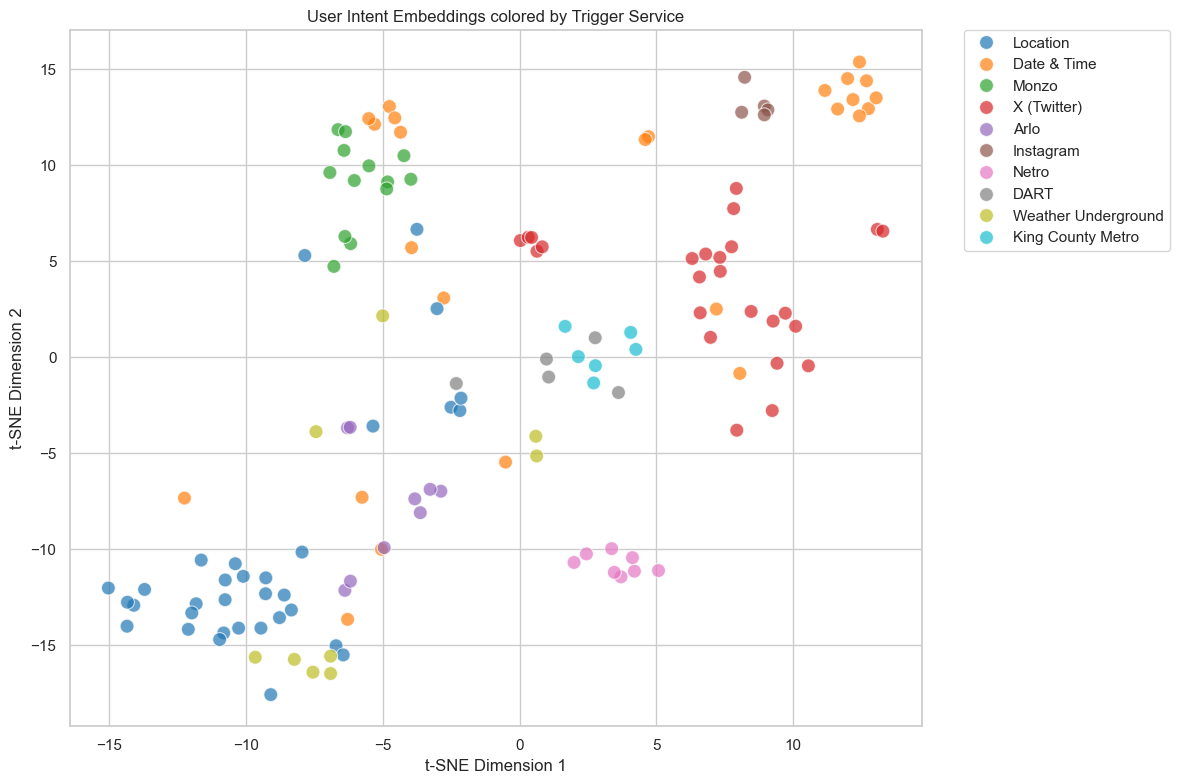

In [8]:
# Plot by Trigger Service
plot_embeddings(df, 'trigger_service_name', 'User Intent Embeddings colored by Trigger Service')

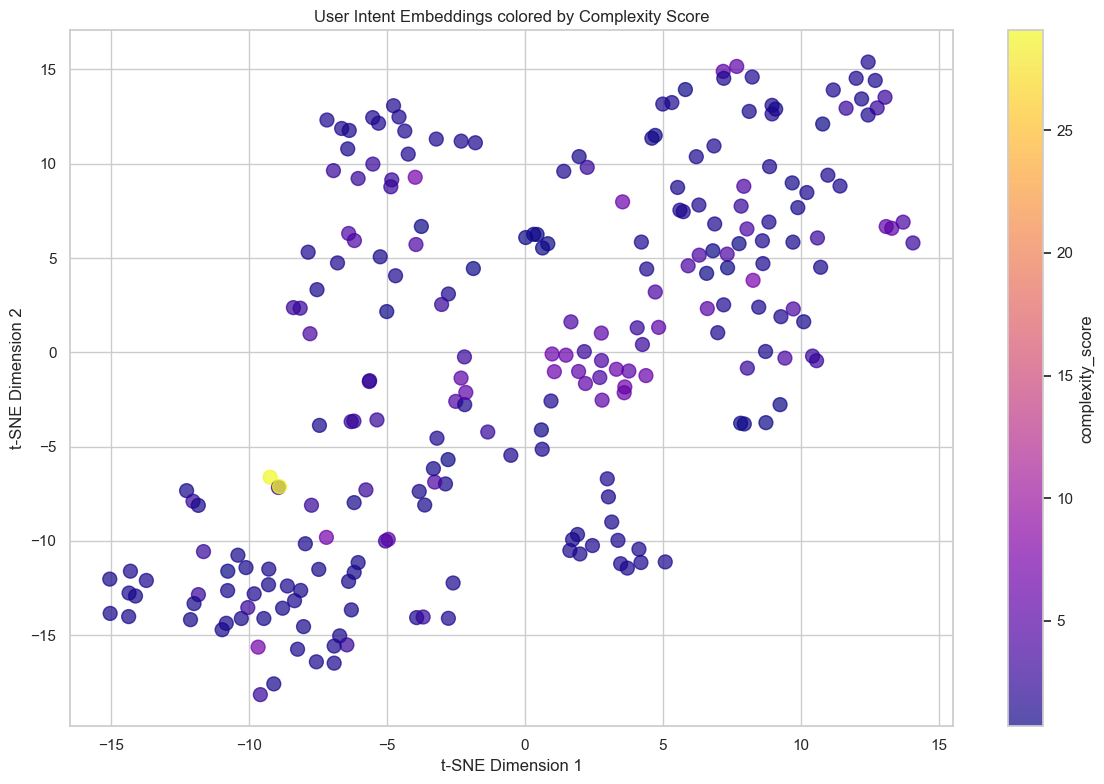

In [9]:
# Plot by Complexity Score
if 'complexity_score' in df.columns:
    plot_embeddings(df, 'complexity_score', 'User Intent Embeddings colored by Complexity Score', cmap='plasma', is_categorical=False)

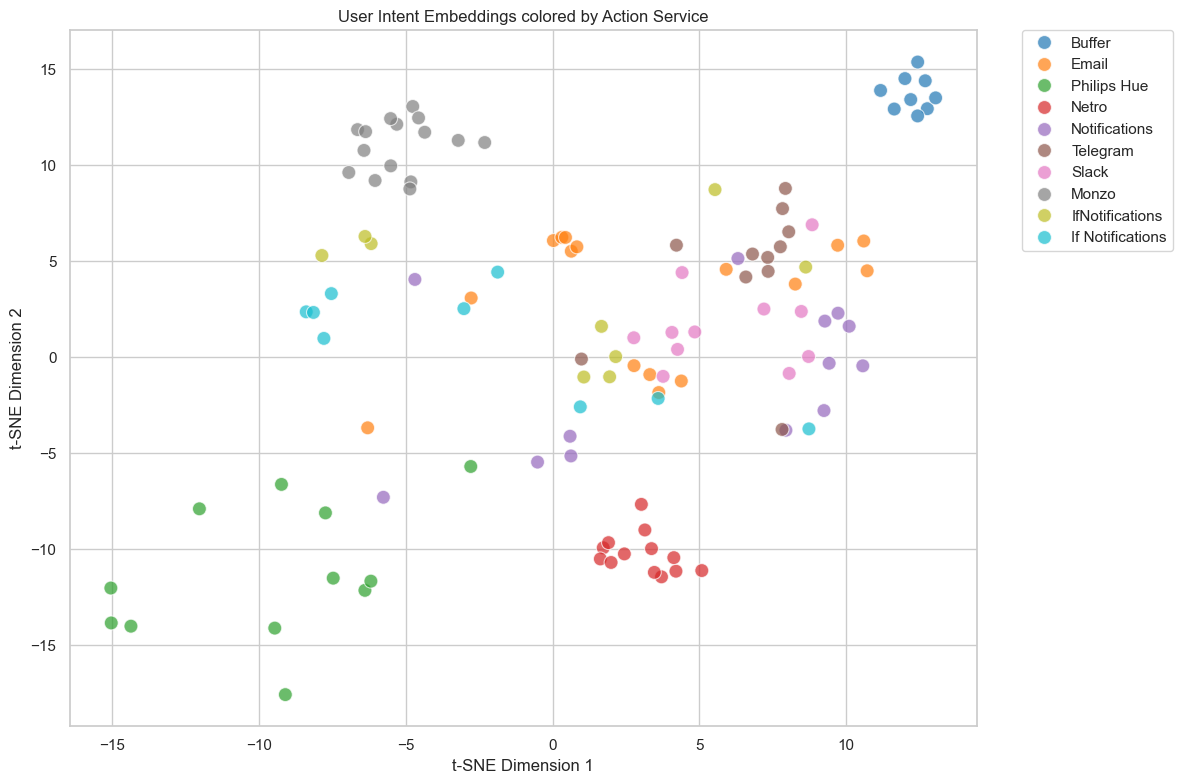

In [10]:
# Plot by Action Service
plot_embeddings(df, 'action_service_name', 'User Intent Embeddings colored by Action Service')